--- composite_runs (/home/goring/mean_field_langevin/MCMC_finiteP/resutls_mf1/d35_k4_biggrid) ---
  γ=0.5  κ=0.0005  P=    10  MSE=2.246042490005493  m_S=1.72847921930952e-06  χ_AA=   4228293.0  runs(mse/mS/chi)=1/1/1
  γ=0.5  κ=0.0005  P=   100  MSE=1.4993659257888794  m_S=4.736926712212153e-05  χ_AA=   4026403.0  runs(mse/mS/chi)=1/1/1
  γ=0.5  κ=0.0005  P=   500  MSE=2.3917810916900635  m_S=0.000493220635689795  χ_AA=  10917032.0  runs(mse/mS/chi)=1/1/1
  γ=0.5  κ=0.0005  P=   750  MSE=1.925155520439148  m_S=0.00888658408075571  χ_AA=  10236923.0  runs(mse/mS/chi)=1/1/1
  γ=0.5  κ=0.0005  P=  1000  MSE=1.59882652759552  m_S=0.04314616695046425  χ_AA=  13355928.0  runs(mse/mS/chi)=1/1/1
  γ=0.5  κ=0.0005  P=  2133  MSE=0.5358816981315613  m_S=1.2551923990249634  χ_AA=  43182892.0  runs(mse/mS/chi)=1/1/1
  γ=0.5  κ=0.0005  P=  3666  MSE=2.3906309604644775  m_S=6.195318222045898  χ_AA=  40742668.0  runs(mse/mS/chi)=1/1/1
  γ=0.5  κ=0.001  P=    10  MSE=1.7790946960449219  m_S=5.5746772

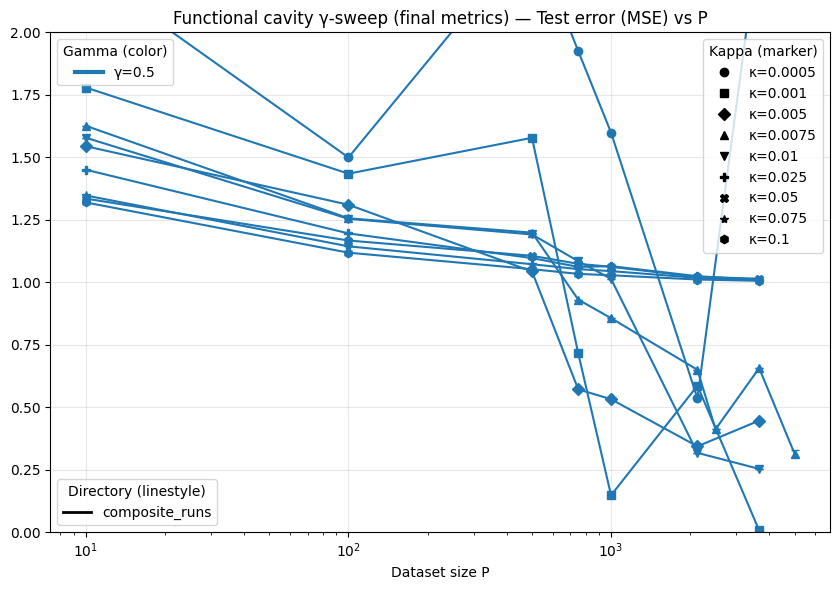

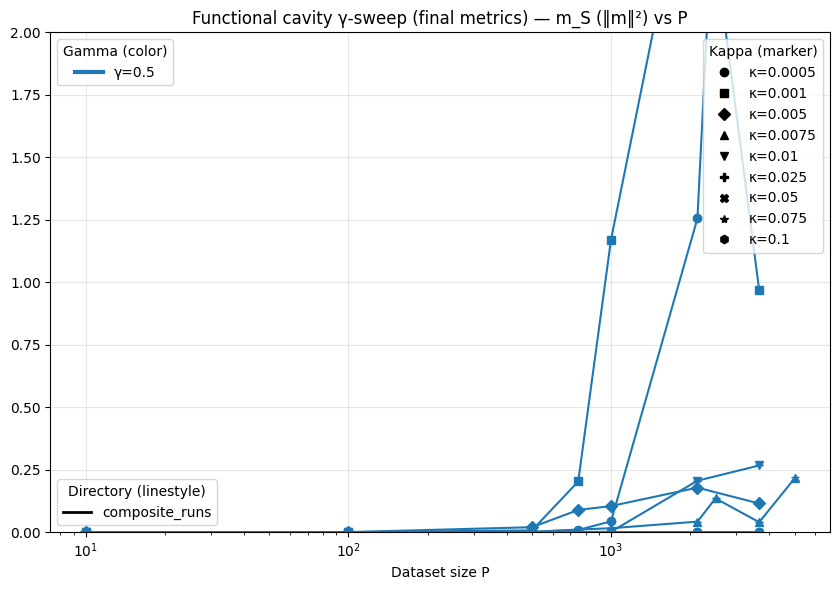

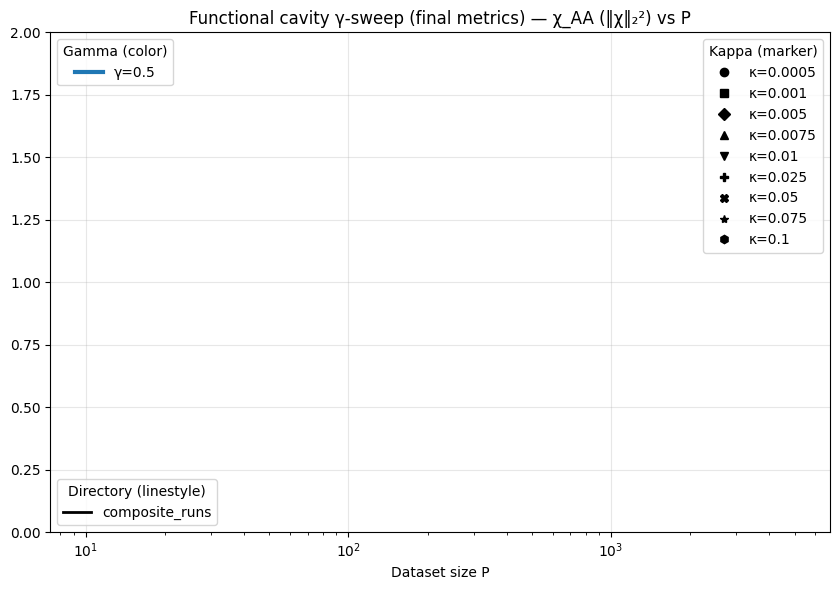

In [1]:
import os, glob, json
from collections import defaultdict
from typing import Dict, Iterable, Tuple, Optional, Union, List
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# If your original has this already, you can remove this fallback.
def _coerce_dir_label_pairs(dirs_and_labels: Union[Dict[str, str], Iterable[Tuple[str, str]]]):
    if isinstance(dirs_and_labels, dict):
        return list(dirs_and_labels.items())
    return list(dirs_and_labels)

def _read_functional_cavity_metrics(path: str) -> Optional[dict]:
    """
    Read a single JSON produced by FunctionalCavitySolver.run(...) and
    normalize the fields we need for plotting.

    Returns a dict with keys:
      P (int), gamma (float), kappa (float),
      mse_total (float), mS_norm2 (float), chi_AA_norm2 (float)
    or None if the file doesn't match/has missing fields.
    """
    try:
        with open(path, "r") as f:
            data = json.load(f)
    except Exception:
        return None

    # Prefer "summary", then fallbacks
    summ = data.get("summary", {})
    cfg  = data.get("config", {})
    mdl  = (cfg.get("mdl", {}) if isinstance(cfg, dict) else {})
    # Extract core scalars robustly
    P = summ.get("P_train")
    if P is None:
        # Try filename heuristic: "..._P<digits>_Neval..."
        bn = os.path.basename(path)
        m = None
        import re
        m = re.search(r"_P(\d+)_", bn)
        if m:
            P = int(m.group(1))
    gamma = summ.get("gamma", mdl.get("gamma"))
    kappa = summ.get("kappa", cfg.get("kappa"))
    mse   = summ.get("mse_total_last", data.get("traj", {}).get("eval_mse_total", [None])[-1] if data.get("traj", {}).get("eval_mse_total") else None)
    mS2   = summ.get("mS_norm2_last")
    chi2  = summ.get("chi_AA_norm2_last")

    # Convert types safely
    def _as_float(x):
        try: return float(x)
        except Exception: return None
    def _as_int(x):
        try: return int(x)
        except Exception: return None

    P     = _as_int(P)
    gamma = _as_float(gamma)
    kappa = _as_float(kappa)
    mse   = _as_float(mse)
    mS2   = _as_float(mS2)
    chi2  = _as_float(chi2)

    if None in (P, gamma, kappa) or (mse is None and mS2 is None and chi2 is None):
        return None

    return {
        "P": P, "gamma": gamma, "kappa": kappa,
        "mse_total": mse, "mS_norm2": mS2, "chi_AA_norm2": chi2
    }

def _aggregate_by_gamma_kappa_P(rows: List[dict]) -> List[dict]:
    """
    Given list of normalized rows (see _read_functional_cavity_metrics),
    aggregate runs with the same (gamma, kappa, P).
    """
    bucket = defaultdict(list)
    for r in rows:
        key = (round(r["gamma"], 12), round(r["kappa"], 12), int(r["P"]))
        bucket[key].append(r)

    out = []
    for (gamma, kappa, P), group in bucket.items():
        def _collect(key):
            vals = [g[key] for g in group if g.get(key) is not None]
            if not vals:
                return None, None, 0
            arr = np.array(vals, dtype=float)
            return float(arr.mean()), float(arr.std(ddof=1) if arr.size > 1 else 0.0), int(arr.size)

        mse_mean,  mse_std,  n_mse  = _collect("mse_total")
        mS_mean,   mS_std,   n_mS   = _collect("mS_norm2")
        chi_mean,  chi_std,  n_chi  = _collect("chi_AA_norm2")

        out.append({
            "gamma": gamma, "kappa": kappa, "P": P,
            "mse_mean": mse_mean, "mse_std_over_runs": mse_std, "n_runs_mse": n_mse,
            "mS_mean":  mS_mean,  "mS_std_over_runs":  mS_std,  "n_runs_mS":  n_mS,
            "chi_mean": chi_mean, "chi_std_over_runs": chi_std, "n_runs_chi": n_chi,
        })
    return out

def make_plots_from_dirs_by_gamma(
    dirs_and_labels: Union[Dict[str, str], Iterable[Tuple[str, str]]],
    *,
    save_png: bool = True,
    out_prefix: str = "gamma_summary",
    verbose: bool = True,
    title_prefix: Optional[str] = None,
):
    """
    NEW: Build three separate figures vs P across multiple GAMMAs (colors),
         optionally multiple KAPPAs (markers), and directories (linestyles).

    Figures produced:
      1) Test error (MSE) vs P
      2) m_S (‖m‖²) vs P
      3) χ_AA (‖χ‖₂²) vs P

    Returns a dict with per-dir aggregates and figure handles.
    """
    pairs = _coerce_dir_label_pairs(dirs_and_labels)

    # 1) Collect & aggregate per directory
    per_dir_agg = {}
    for (results_dir, label) in pairs:
        paths = glob.glob(os.path.join(results_dir, "*.json"))
        rows = []
        for p in paths:
            r = _read_functional_cavity_metrics(p)
            if r is not None:
                rows.append(r)

        if not rows:
            if verbose:
                print(f"[warn] No usable result JSONs in {results_dir}")
            per_dir_agg[label] = []
            continue

        agg = _aggregate_by_gamma_kappa_P(rows)
        if verbose:
            print(f"--- {label} ({results_dir}) ---")
            for r in sorted(agg, key=lambda t: (t["gamma"], t["kappa"], t["P"])):
                gm = r["gamma"]; kp = r["kappa"]; P = r["P"]
                print(f"  γ={gm:g}  κ={kp:g}  P={P:>6d}  "
                      f"MSE={r['mse_mean']!s:>12}  m_S={r['mS_mean']!s:>12}  χ_AA={r['chi_mean']!s:>12}  "
                      f"runs(mse/mS/chi)={r['n_runs_mse']}/{r['n_runs_mS']}/{r['n_runs_chi']}")
        per_dir_agg[label] = agg

    # 2) Style maps
    # Colors by GAMMA
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key().get('color', []) or [f"C{i}" for i in range(10)]
    gammas_all = sorted(set(round(r["gamma"], 12) for agg in per_dir_agg.values() for r in agg))
    gamma_color = {g: color_cycle[i % len(color_cycle)] for i, g in enumerate(gammas_all)}

    # Linestyles by DIRECTORY (label)
    linestyle_choices = [
        "-", "--", ":", "-.", (0, (3,1,1,1)), (0, (5,5)), (0, (1,1)), (0, (5,1)), (0,(2,2,1,2))
    ]
    dir_linestyle = {label: linestyle_choices[i % len(linestyle_choices)]
                     for i, (_, label) in enumerate(pairs)}

    # Markers by KAPPA
    marker_choices = ["o", "s", "D", "^", "v", "P", "X", "*", "h", "8"]
    kappas_all = sorted(set(round(r["kappa"], 12) for agg in per_dir_agg.values() for r in agg))
    kappa_marker = {k: marker_choices[i % len(marker_choices)] for i, k in enumerate(kappas_all)}

    # 3) Plot helpers
    def _plot_metric(metric_key_mean, metric_key_std, ylabel, out_name):
        fig, ax = plt.subplots(figsize=(8.5, 6))
        # keep track for legends
        used_gamma = set()
        used_kappa = set()
        used_dir   = set()

        for (results_dir, label) in pairs:
            agg = per_dir_agg.get(label, [])
            # group by (gamma, kappa)
            by_gk = defaultdict(list)
            for r in agg:
                by_gk[(r["gamma"], r["kappa"])].append(r)

            for (gamma, kappa), rows_gk in sorted(by_gk.items(), key=lambda t: (t[0][0], t[0][1])):
                rows_sorted = sorted(rows_gk, key=lambda r: r["P"])
                Ps   = np.array([r["P"] for r in rows_sorted], dtype=int)
                vals = np.array([r[metric_key_mean] for r in rows_sorted], dtype=float)
                yerr = np.array([r[metric_key_std] for r in rows_sorted], dtype=float)

                # Hide missing values (None) gracefully
                mask = np.isfinite(vals)
                if not mask.any():
                    continue
                Ps, vals, yerr = Ps[mask], vals[mask], yerr[mask]

                ax.errorbar(
                    Ps, vals, yerr=yerr, capsize=3,
                    marker=kappa_marker[round(kappa,12)],
                    linestyle=dir_linestyle[label],
                    color=gamma_color[round(gamma,12)],
                    label=None,
                )

                used_gamma.add(round(gamma,12))
                used_kappa.add(round(kappa,12))
                used_dir.add(label)

        ax.set_xscale("log")  # P usually spans decades; tweak if you prefer linear
        ax.set_xlabel("Dataset size P")
        ax.set_ylim(0,2)
        base_title = title_prefix or "Cavity functional summary"
        ax.set_title(f"{base_title} — {ylabel} vs P")
        ax.grid(True, alpha=0.3)

        # Legends
        gamma_handles = [Line2D([0],[0], color=gamma_color[g], lw=3, label=f"γ={g:g}") for g in gammas_all if g in used_gamma]
        kappa_handles = [Line2D([0],[0], marker=kappa_marker[k], linestyle="None", color="black", label=f"κ={k:g}") for k in kappas_all if k in used_kappa]
        dir_handles   = [Line2D([0],[0], color="black", linestyle=dir_linestyle[d], lw=2, label=d) for d in [lab for (_, lab) in pairs] if d in used_dir]

        # place 3 legends neatly
        if gamma_handles:
            leg1 = ax.legend(handles=gamma_handles, title="Gamma (color)", loc="upper left")
            ax.add_artist(leg1)
        if kappa_handles:
            leg2 = ax.legend(handles=kappa_handles, title="Kappa (marker)", loc="upper right")
            ax.add_artist(leg2)
        if dir_handles:
            ax.legend(handles=dir_handles, title="Directory (linestyle)", loc="lower left")

        fig.tight_layout()
        if save_png:
            out_path = f"{out_prefix}_{out_name}.png"
            fig.savefig(out_path, dpi=150)
            if verbose:
                print(f"[saved plot] {out_path}")
        return fig, ax

    # 4) Make the three separate figures
    fig_mse, ax_mse = _plot_metric("mse_mean", "mse_std_over_runs", "Test error (MSE)", "mse_vs_P")
    fig_mS,  ax_mS  = _plot_metric("mS_mean",  "mS_std_over_runs",  "m_S (‖m‖²)",     "mS_vs_P")
    fig_chi, ax_chi = _plot_metric("chi_mean", "chi_std_over_runs", "χ_AA (‖χ‖₂²)",  "chiAA_vs_P")

    return {
        "per_dir_agg": per_dir_agg,
        "figs": {
            "mse": (fig_mse, ax_mse),
            "mS":  (fig_mS,  ax_mS),
            "chi": (fig_chi, ax_chi),
        },
        "styles": {
            "gamma_color": gamma_color,
            "kappa_marker": kappa_marker,
            "dir_linestyle": dir_linestyle,
        },
        "values_present": {
            "gammas": gammas_all,
            "kappas": kappas_all,
        }
    }

# -------------- example usage (separate from your original) --------------
if __name__ == "__main__":
    pairs = [
        ("/home/goring/mean_field_langevin/MCMC_finiteP/resutls_mf1/d35_k4_biggrid", "composite_runs"),
        # add more result folders if you want distinct linestyles
    ]
    out = make_plots_from_dirs_by_gamma(
        pairs,
        save_png=True,
        out_prefix="functional_cavity_gamma_summaries",
        title_prefix="Functional cavity γ-sweep (final metrics)"
    )
    # In a notebook, you can display: out["figs"]["mse"][0], out["figs"]["mS"][0], out["figs"]["chi"][0]

--- RS_AW_ARD (/home/goring/mean_field_langevin/MCMC_sparse/results/d35_k4_grid_3008_a01e-2_75e-3_2) ---
  κ=0.0075  γ=0.5  P=    10  MSE(total_ms)=1.3196611353801018 ± 0.04599987734880293 (files=1)   ‖m_S‖²=1.4737343427997701e-05 ± 1.3753085101424387e-05 (files=1)
  κ=0.0075  γ=0.5  P=   100  MSE(total_ms)=1.47068377992188 ± 0.03480497324630145 (files=1)   ‖m_S‖²=9.281827137182729e-06 ± 5.884188573879442e-08 (files=1)
  κ=0.0075  γ=0.5  P=   500  MSE(total_ms)=1.2372336346196182 ± 0.002973332095656927 (files=1)   ‖m_S‖²=0.00010701435174503866 ± 0.00010769190299266793 (files=1)
  κ=0.0075  γ=0.5  P=   750  MSE(total_ms)=0.03168744966387749 ± 0.0012577741167890376 (files=1)   ‖m_S‖²=0.6805440897428122 ± 0.005487839121079813 (files=1)
  κ=0.0075  γ=0.5  P=  1000  MSE(total_ms)=0.030088833222786587 ± 0.0007984733054500492 (files=1)   ‖m_S‖²=0.6879792133854075 ± 0.0017694915269964517 (files=1)
  κ=0.0075  γ=0.5  P=  2133  MSE(total_ms)=0.029370575522383053 ± 0.0012093617343392924 (files=1)

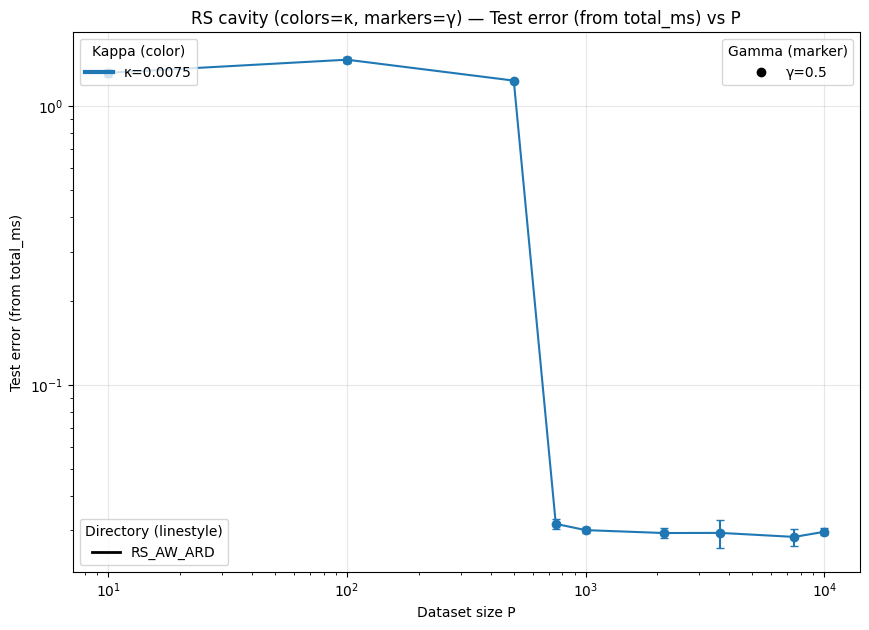

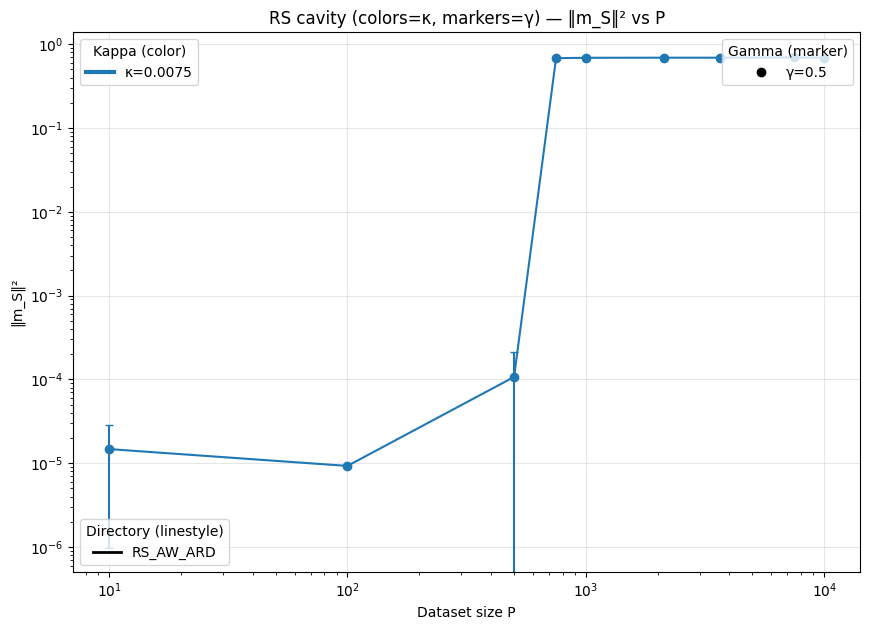

In [2]:
import os, glob, json, re
from collections import defaultdict
from typing import Dict, Iterable, Tuple, Optional, Union, List
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ----------------------- helpers -----------------------

def _coerce_dir_label_pairs(dirs_and_labels: Union[Dict[str, str], Iterable[Tuple[str, str]]]):
    if isinstance(dirs_and_labels, dict):
        return list(dirs_and_labels.items())
    return list(dirs_and_labels)

def _safe_last(seq, default=None):
    try:
        return seq[-1]
    except Exception:
        return default

def _parse_P_from_basename(bn: str) -> Optional[int]:
    # matches ... _Ptr{P}_ ...
    m = re.search(r"_Ptr(\d+)_", bn)
    return int(m.group(1)) if m else None

def _parse_kappa_from_basename(bn: str) -> Optional[float]:
    # matches ... _kap{float}_ ...
    m = re.search(r"_kap([0-9eE+\-\.]+)_", bn)
    try:
        return float(m.group(1)) if m else None
    except Exception:
        return None

def _read_rs_json(path: str) -> Optional[dict]:
    """Read JSON structure produced by rs_cavity_explicit_aw_ard.py and return dict with:
       P, gamma, kappa,
       test_total_ms_mean_E, test_total_ms_std_E,
       test_empirical_mean_E (if available), test_empirical_std_E (if available),
       mS_norm2_mean_E, mS_norm2_std_E
    """
    try:
        with open(path, "r") as f:
            data = json.load(f)
    except Exception:
        return None

    cfg = data.get("config", {}) or {}
    mdl = cfg.get("model", {}) or {}
    gamma = mdl.get("gamma", None)
    kappa = cfg.get("kappa", None)

    bn = os.path.basename(path)
    P = _parse_P_from_basename(bn)
    if kappa is None:
        kappa = _parse_kappa_from_basename(bn)

    traj = data.get("traj", {}) or {}

    # ---- 1) test error via half_mse_total_ms_per_exp (per replica) ----
    half_total_per_exp_all = traj.get("half_mse_total_ms_per_exp", [])
    half_total_last = _safe_last(half_total_per_exp_all)
    test_total_ms_mean_E = None
    test_total_ms_std_E = None
    if isinstance(half_total_last, list) and len(half_total_last) > 0:
        vals = np.array(half_total_last, dtype=float)  # shape: (E,)
        # convert half-MSE -> full MSE
        vals_full = 2.0 * vals
        test_total_ms_mean_E = float(np.mean(vals_full))
        test_total_ms_std_E = float(np.std(vals_full, ddof=1) if vals_full.size > 1 else 0.0)

    # ---- 2) optional empirical error via half_mse_empirical_per_exp (per replica) ----
    half_emp_per_exp_all = traj.get("half_mse_empirical_per_exp", [])
    half_emp_last = _safe_last(half_emp_per_exp_all)
    test_empirical_mean_E = None
    test_empirical_std_E = None
    if isinstance(half_emp_last, list) and len(half_emp_last) > 0:
        vals = np.array(half_emp_last, dtype=float)  # (E,)
        vals_full = 2.0 * vals
        test_empirical_mean_E = float(np.mean(vals_full))
        test_empirical_std_E = float(np.std(vals_full, ddof=1) if vals_full.size > 1 else 0.0)

    # ---- 3) m_S per replica -> norm^2 per replica ----
    mS_per_exp_all = traj.get("m_S_per_exp", [])
    mS_last = _safe_last(mS_per_exp_all)
    mS_norm2_mean_E = None
    mS_norm2_std_E = None
    if isinstance(mS_last, list) and len(mS_last) > 0:
        # mS_last is a list of length E; each item is a list (vector of mode coefficients)
        norms = []
        for e_item in mS_last:
            try:
                v = np.array(e_item, dtype=float).reshape(-1)  # flatten M x (possibly 1) -> (M,)
                norms.append(float(np.dot(v, v)))
            except Exception:
                pass
        if norms:
            arr = np.array(norms, dtype=float)
            mS_norm2_mean_E = float(np.mean(arr))
            mS_norm2_std_E  = float(np.std(arr, ddof=1) if arr.size > 1 else 0.0)

    if None in (P, gamma, kappa):
        return None

    return {
        "P": int(P),
        "gamma": float(gamma),
        "kappa": float(kappa),
        "test_total_ms_mean_E": test_total_ms_mean_E,
        "test_total_ms_std_E":  test_total_ms_std_E,
        "test_empirical_mean_E": test_empirical_mean_E,
        "test_empirical_std_E":  test_empirical_std_E,
        "mS_norm2_mean_E": mS_norm2_mean_E,
        "mS_norm2_std_E":  mS_norm2_std_E,
    }

def _aggregate_across_files(rows: List[dict]) -> List[dict]:
    """
    Group by (gamma, kappa, P). Within each file we already computed
    mean±std across replicas E. Now combine across files (if multiple).
    Error bar policy:
      - If multiple files per (γ,κ,P): y = mean of file-means; err = std of file-means.
      - If only one file: y = that file's mean; err = that file's std across E.
    """
    bucket = defaultdict(list)
    for r in rows:
        key = (round(r["gamma"], 12), round(r["kappa"], 12), int(r["P"]))
        bucket[key].append(r)

    def _combine(key_mean, key_std, group):
        means = [g[key_mean] for g in group if g.get(key_mean) is not None]
        stds  = [g[key_std]  for g in group if g.get(key_std)  is not None]
        if not means:
            return None, None, 0
        arr_means = np.array(means, dtype=float)
        if len(means) > 1:
            y  = float(np.mean(arr_means))
            ye = float(np.std(arr_means, ddof=1))
        else:
            y  = float(arr_means[0])
            ye = float(stds[0] if stds else 0.0)
        return y, ye, len(means)

    out = []
    for (gamma, kappa, P), group in bucket.items():
        mse_y, mse_ye, n_mse = _combine("test_total_ms_mean_E", "test_total_ms_std_E", group)
        emp_y, emp_ye, n_emp = _combine("test_empirical_mean_E", "test_empirical_std_E", group)
        ms_y,  ms_ye,  n_ms  = _combine("mS_norm2_mean_E", "mS_norm2_std_E", group)
        out.append({
            "gamma": gamma, "kappa": kappa, "P": P,
            "mse_mean": mse_y, "mse_err": mse_ye, "n_files_mse": n_mse,
            "emp_mean": emp_y, "emp_err": emp_ye, "n_files_emp": n_emp,
            "mS_mean":  ms_y,  "mS_err":  ms_ye,  "n_files_mS":  n_ms,
        })
    return out

# ----------------------- plotting -----------------------

def plot_rs_aw_results(
    dirs_and_labels: Union[Dict[str, str], Iterable[Tuple[str, str]]],
    *,
    save_png: bool = True,
    out_prefix: str = "rs_aw_summary",
    verbose: bool = True,
    title_prefix: Optional[str] = None,
    xscale_log: bool = True,
    ylim_mse: Optional[Tuple[float, float]] = None,
    ylim_mS: Optional[Tuple[float, float]] = None,
    also_plot_empirical: bool = False,
):
    """
    Build figures vs P with:
      - Test error (from half_mse_total_ms_per_exp): mean±std over replicas E (colors=κ, markers=γ).
      - ‖m_S‖² (from m_S_per_exp): mean±std over replicas E.

    If multiple JSONs share (γ, κ, P), the point is the mean of per-file means,
    and the error bar is the std across per-file means. With a single file, the
    error bar is the std across replicas E from that file.
    """
    pairs = _coerce_dir_label_pairs(dirs_and_labels)

    # 1) Read & aggregate per directory
    per_dir_agg = {}
    for (results_dir, label) in pairs:
        paths = glob.glob(os.path.join(results_dir, "*.json"))
        rows = []
        for p in paths:
            r = _read_rs_json(p)
            if r is not None:
                rows.append(r)
        if not rows:
            if verbose:
                print(f"[warn] No usable result JSONs in {results_dir}")
            per_dir_agg[label] = []
            continue

        agg = _aggregate_across_files(rows)
        if verbose:
            print(f"--- {label} ({results_dir}) ---")
            for r in sorted(agg, key=lambda t: (t["kappa"], t["gamma"], t["P"])):
                print(f"  κ={r['kappa']:g}  γ={r['gamma']:g}  P={r['P']:>6d}  "
                      f"MSE(total_ms)={r['mse_mean']!s} ± {r['mse_err']!s} (files={r['n_files_mse']})   "
                      f"‖m_S‖²={r['mS_mean']!s} ± {r['mS_err']!s} (files={r['n_files_mS']})")
                if also_plot_empirical and r["emp_mean"] is not None:
                    print(f"    Empirical MSE={r['emp_mean']!s} ± {r['emp_err']!s} (files={r['n_files_emp']})")
        per_dir_agg[label] = agg

    # 2) Styles
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key().get('color', []) or [f"C{i}" for i in range(10)]
    kappas_all = sorted(set(round(r["kappa"], 12) for agg in per_dir_agg.values() for r in agg))
    kappa_color = {k: color_cycle[i % len(color_cycle)] for i, k in enumerate(kappas_all)}

    marker_choices = ["o", "s", "D", "^", "v", "P", "X", "*", "h", "8"]
    gammas_all = sorted(set(round(r["gamma"], 12) for agg in per_dir_agg.values() for r in agg))
    gamma_marker = {g: marker_choices[i % len(marker_choices)] for i, g in enumerate(gammas_all)}

    linestyle_choices = ["-", "--", ":", "-.", (0,(3,1,1,1)), (0,(5,5)), (0,(1,1)), (0,(5,1)), (0,(2,2,1,2))]
    dir_linestyle = {label: linestyle_choices[i % len(linestyle_choices)]
                     for i, (_, label) in enumerate(pairs)}

    # 3) Plot helper
    def _plot_metric(mean_key, err_key, ylabel, out_name, ylim=None):
        fig, ax = plt.subplots(figsize=(8.8, 6.4))
        used_kappa, used_gamma, used_dir = set(), set(), set()

        for (results_dir, label) in pairs:
            agg = per_dir_agg.get(label, [])
            by_kg = defaultdict(list)
            for r in agg:
                by_kg[(r["kappa"], r["gamma"])].append(r)

            for (kappa, gamma), rows_kg in sorted(by_kg.items(), key=lambda t: (t[0][0], t[0][1])):
                rows_sorted = sorted(rows_kg, key=lambda r: r["P"])
                Ps   = np.array([r["P"] for r in rows_sorted], dtype=int)
                vals = np.array([r[mean_key] for r in rows_sorted], dtype=float)
                yerr = np.array([r[err_key]  for r in rows_sorted], dtype=float)

                mask = np.isfinite(vals)
                if not mask.any():
                    continue
                Ps, vals, yerr = Ps[mask], vals[mask], yerr[mask]

                ax.errorbar(
                    Ps, vals, yerr=yerr, capsize=3,
                    marker=gamma_marker[round(gamma,12)],
                    linestyle=dir_linestyle[label],
                    color=kappa_color[round(kappa,12)],
                    label=None,
                )
                used_kappa.add(round(kappa,12))
                used_gamma.add(round(gamma,12))
                used_dir.add(label)

        if xscale_log: 
            ax.set_xscale("log")
            ax.set_yscale("log")

        #ax.set_yscale("linear")
        ax.set_xlabel("Dataset size P")
        ax.set_ylabel(ylabel)
        if ylim is not None: ax.set_ylim(*ylim)
        ax.grid(True, alpha=0.3)
        base_title = title_prefix or "RS cavity summary"
        ax.set_title(f"{base_title} — {ylabel} vs P")

        kappa_handles = [Line2D([0],[0], color=kappa_color[k], lw=3, label=f"κ={k:g}") for k in kappas_all if k in used_kappa]
        gamma_handles = [Line2D([0],[0], marker=gamma_marker[g], linestyle="None", color="black", label=f"γ={g:g}") for g in gammas_all if g in used_gamma]
        dir_handles   = [Line2D([0],[0], color="black", linestyle=dir_linestyle[d], lw=2, label=d) for d in [lab for (_, lab) in pairs] if d in used_dir]

        if kappa_handles:
            leg1 = ax.legend(handles=kappa_handles, title="Kappa (color)", loc="upper left"); ax.add_artist(leg1)
        if gamma_handles:
            leg2 = ax.legend(handles=gamma_handles, title="Gamma (marker)", loc="upper right"); ax.add_artist(leg2)
        if dir_handles:
            ax.legend(handles=dir_handles, title="Directory (linestyle)", loc="lower left")

        fig.tight_layout()
        if save_png:
            out_path = f"{out_prefix}_{out_name}.png"
            fig.savefig(out_path, dpi=150)
            print(f"[saved plot] {out_path}")
        return fig, ax

    # 4) Figures
    fig_mse, ax_mse = _plot_metric("mse_mean", "mse_err", "Test error (from total_ms)", "mse_vs_P", ylim=ylim_mse)
    fig_mS,  ax_mS  = _plot_metric("mS_mean",  "mS_err",  "‖m_S‖²",                   "mS_vs_P",  ylim=ylim_mS)

    # Optional empirical test error (from half_mse_empirical_per_exp)
    if also_plot_empirical:
        _plot_metric("emp_mean", "emp_err", "Test error (empirical)", "mse_empirical_vs_P", ylim=ylim_mse)

    return {
        "per_dir_agg": per_dir_agg,
        "figs": {"mse_total_ms": (fig_mse, ax_mse), "mS": (fig_mS, ax_mS)},
        "styles": {"kappa_color": kappa_color, "gamma_marker": gamma_marker, "dir_linestyle": dir_linestyle},
        "values_present": {"gammas": gammas_all, "kappas": kappas_all},
    }

# ---------------- example usage ----------------
if __name__ == "__main__":
    pairs = [
        ("/home/goring/mean_field_langevin/MCMC_sparse/results/d35_k4_grid_3008_a01e-2_75e-3_2", "RS_AW_ARD"),
        # add more (dir, label) tuples if you want distinct linestyles
    ]
    _ = plot_rs_aw_results(
        pairs,
        save_png=True,
        out_prefix="rs_aw_gamma_kappa_summaries",
        title_prefix="RS cavity (colors=κ, markers=γ)",
        xscale_log=True,
        # ylim_mse=(0.0, 1.0),
        # ylim_mS=(0.0, 1.0),
        also_plot_empirical=False,  # set True to also generate empirical-MSE figure
    )


--- RS_AW_ARD (/home/goring/mean_field_langevin/MCMC_sparse/results/d35_k4_grid_3008_a0.5_75e-3) ---
  κ=0.0075  γ=0.5  P=    10  MSE(total_ms)=1.3169289955483616 ± 0.0737283006752319 (files=1)   ‖m_S‖²=9.712677616851149e-06 ± 9.746682046273674e-06 (files=1)
  κ=0.0075  γ=0.5  P=   100  MSE(total_ms)=1.466094175152648 ± 0.03339165555372167 (files=1)   ‖m_S‖²=9.736247063956107e-06 ± 2.7648497742313646e-06 (files=1)
  κ=0.0075  γ=0.5  P=   750  MSE(total_ms)=0.044211484491825104 ± 0.006551418966607979 (files=1)   ‖m_S‖²=0.6375441923361423 ± 0.024969630802651837 (files=1)
  κ=0.0075  γ=0.5  P= 10000  MSE(total_ms)=0.03887440264225006 ± 0.0016922170147910978 (files=1)   ‖m_S‖²=0.6525011801897129 ± 0.005803842759411992 (files=1)
[saved plot] rs_aw_gamma_kappa_summaries_mse_vs_P.png
[saved plot] rs_aw_gamma_kappa_summaries_mS_vs_P.png


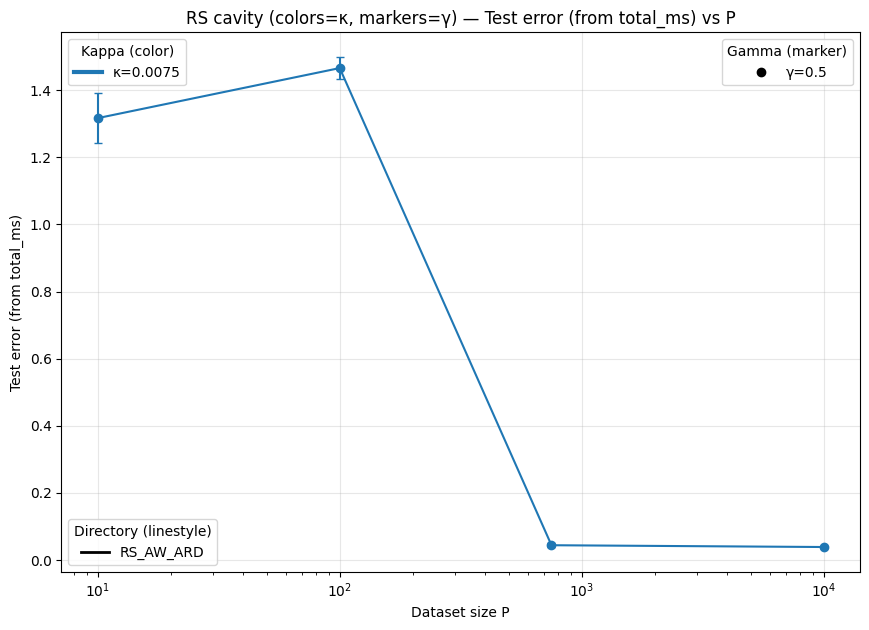

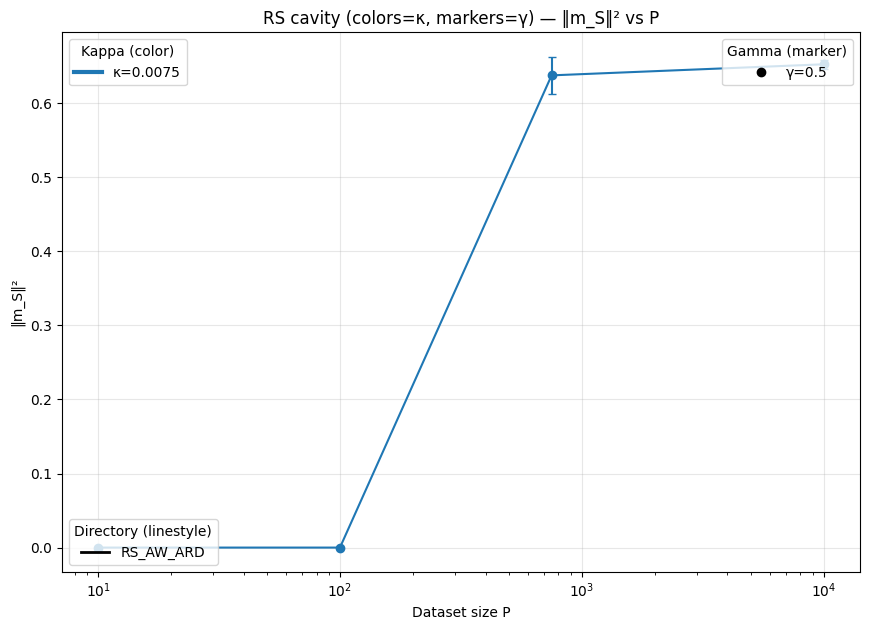

In [9]:
if __name__ == "__main__":
    pairs = [
        ("/home/goring/mean_field_langevin/MCMC_sparse/results/d35_k4_grid_3008_a0.5_75e-3", "RS_AW_ARD"),
        # add more (dir, label) tuples if you want distinct linestyles
    ]
    _ = plot_rs_aw_results(
        pairs,
        save_png=True,
        out_prefix="rs_aw_gamma_kappa_summaries",
        title_prefix="RS cavity (colors=κ, markers=γ)",
        xscale_log=True,
        # ylim_mse=(0.0, 1.0),
        # ylim_mS=(0.0, 1.0),
        also_plot_empirical=False,  # set True to also generate empirical-MSE figure
    )

--- RS_AW_ARD (/home/goring/mean_field_langevin/MCMC_sparse/results/d35_k4_grid_3008_a50_75e-3) ---
  κ=0.0075  γ=0.5  P=    10  MSE(total_ms)=1.3400608719388554 ± 0.046830528264983344 (files=1)   ‖m_S‖²=9.16709504901729e-06 ± 8.789796550634537e-06 (files=1)
  κ=0.0075  γ=0.5  P=   100  MSE(total_ms)=1.4052742168926973 ± 0.0444574963578125 (files=1)   ‖m_S‖²=8.797086890999613e-06 ± 9.594049168695165e-06 (files=1)
  κ=0.0075  γ=0.5  P=   750  MSE(total_ms)=0.6919442760602882 ± 0.4761952107011271 (files=1)   ‖m_S‖²=0.13628623337000226 ± 0.21409249496636584 (files=1)
  κ=0.0075  γ=0.5  P=  1000  MSE(total_ms)=0.10509915401538213 ± 0.01889737925604452 (files=1)   ‖m_S‖²=0.48020832176199946 ± 0.037568786282802795 (files=1)
  κ=0.0075  γ=0.5  P= 10000  MSE(total_ms)=0.12770857413609824 ± 0.0069730536389333965 (files=1)   ‖m_S‖²=0.4208302175008238 ± 0.013284428913334053 (files=1)
[saved plot] rs_aw_gamma_kappa_summaries_mse_vs_P.png
[saved plot] rs_aw_gamma_kappa_summaries_mS_vs_P.png


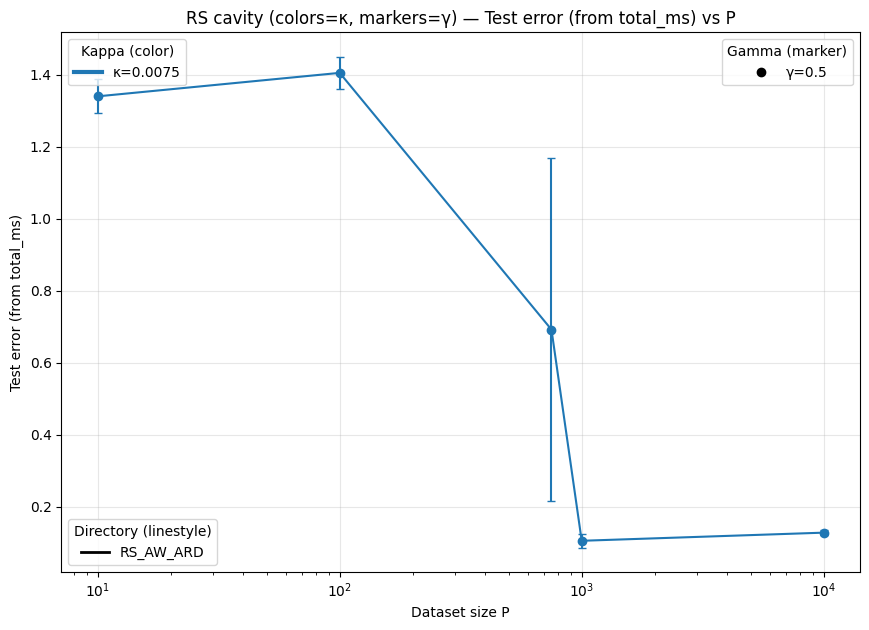

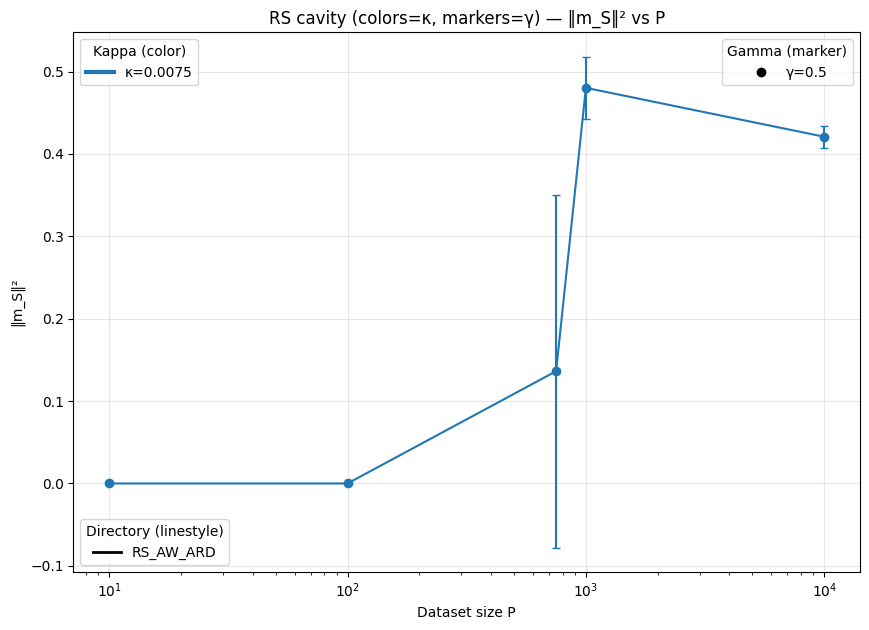

In [18]:
if __name__ == "__main__":
    pairs = [
        ("/home/goring/mean_field_langevin/MCMC_sparse/results/d35_k4_grid_3008_a50_75e-3", "RS_AW_ARD"),
        # add more (dir, label) tuples if you want distinct linestyles
    ]
    _ = plot_rs_aw_results(
        pairs,
        save_png=True,
        out_prefix="rs_aw_gamma_kappa_summaries",
        title_prefix="RS cavity (colors=κ, markers=γ)",
        xscale_log=True,
        # ylim_mse=(0.0, 1.0),
        # ylim_mS=(0.0, 1.0),
        also_plot_empirical=False,  # set True to also generate empirical-MSE figure
    )

--- RS_AW_ARD (/home/goring/mean_field_langevin/MCMC_sparse/results/d35_k4_grid_3008_a1_75e-3) ---
  κ=0.0075  γ=0.5  P=    10  MSE(total_ms)=1.3681337592901741 ± 0.07213644626460575 (files=1)   ‖m_S‖²=1.3107269927072749e-05 ± 1.7471857070364355e-05 (files=1)
  κ=0.0075  γ=0.5  P=   100  MSE(total_ms)=1.4634828512657805 ± 0.021545653335249663 (files=1)   ‖m_S‖²=6.879886922227898e-06 ± 2.8019024473718266e-06 (files=1)
  κ=0.0075  γ=0.5  P=   750  MSE(total_ms)=0.04027188445130984 ± 0.0020583387089252655 (files=1)   ‖m_S‖²=0.6510984360840434 ± 0.008106525434376717 (files=1)
  κ=0.0075  γ=0.5  P= 10000  MSE(total_ms)=0.03917960450053215 ± 0.001478452519764628 (files=1)   ‖m_S‖²=0.6508924179864432 ± 0.006728873053986656 (files=1)
[saved plot] rs_aw_gamma_kappa_summaries_mse_vs_P.png
[saved plot] rs_aw_gamma_kappa_summaries_mS_vs_P.png


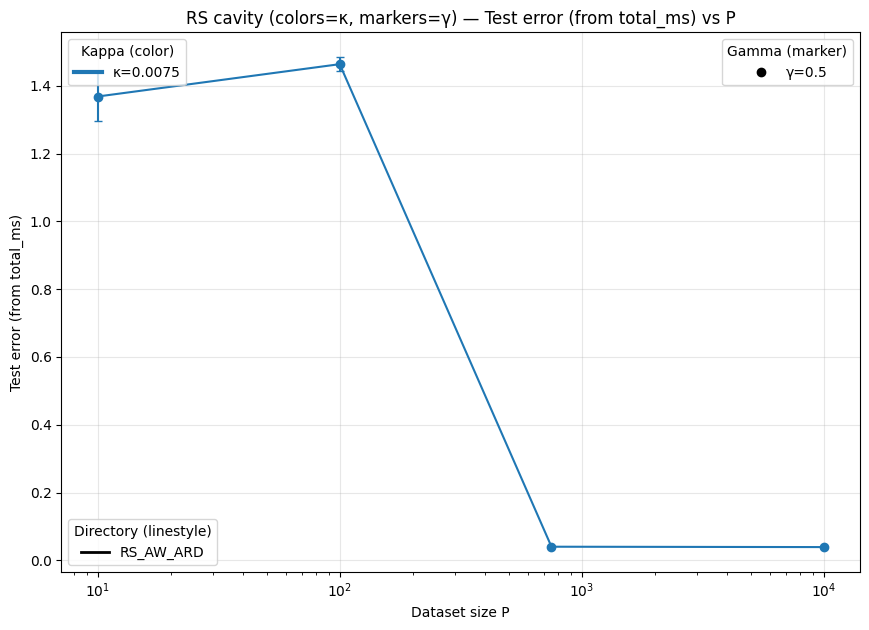

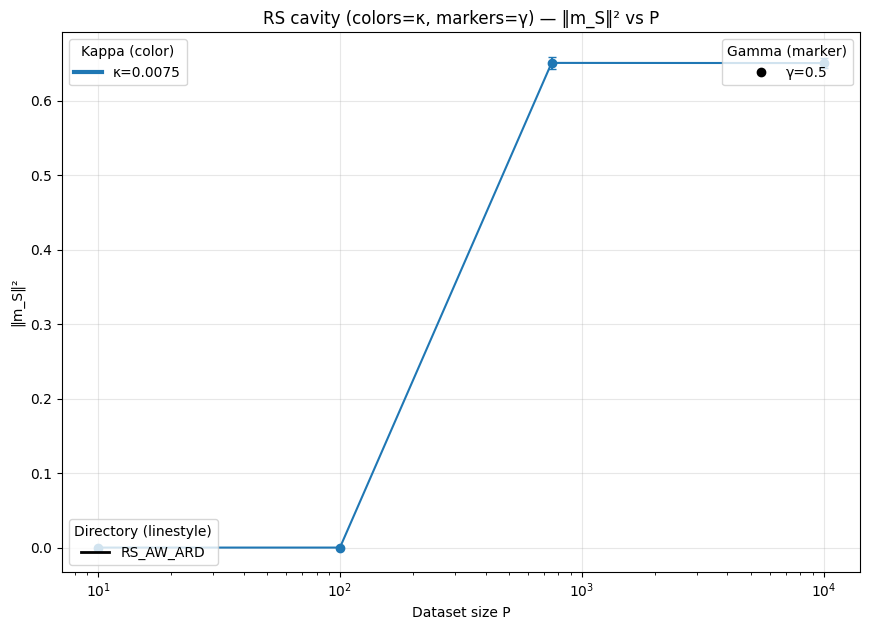

In [2]:
if __name__ == "__main__":
    pairs = [
        ("/home/goring/mean_field_langevin/MCMC_sparse/results/d35_k4_grid_3008_a1_75e-3", "RS_AW_ARD"),
        # add more (dir, label) tuples if you want distinct linestyles
    ]
    _ = plot_rs_aw_results(
        pairs,
        save_png=True,
        out_prefix="rs_aw_gamma_kappa_summaries",
        title_prefix="RS cavity (colors=κ, markers=γ)",
        xscale_log=True,
        # ylim_mse=(0.0, 1.0),
        # ylim_mS=(0.0, 1.0),
        also_plot_empirical=False,  # set True to also generate empirical-MSE figure
    )

--- RS_AW_ARD (/home/goring/mean_field_langevin/MCMC_sparse/results/d35_k4_3108_a1grid) ---
  κ=0.0005  γ=0.5  P= 10000  MSE(total_ms)=1.2281567298341542 ± 0.37058100324394094 (files=1)   ‖m_S‖²=0.012673929632502953 ± 0.020531470721783705 (files=1)
  κ=0.001  γ=0.5  P= 10000  MSE(total_ms)=2.6506211360295615 ± 0.4094753720682406 (files=1)   ‖m_S‖²=0.031809548139458244 ± 0.021699612739513204 (files=1)
  κ=0.005  γ=0.5  P=    10  MSE(total_ms)=1.5906370595130284 ± 0.03509393893238701 (files=1)   ‖m_S‖²=1.824746192219323e-05 ± 5.506628933043808e-06 (files=1)
  κ=0.005  γ=0.5  P= 10000  MSE(total_ms)=0.02169996437927087 ± 0.0006996654714699348 (files=1)   ‖m_S‖²=0.733838676591637 ± 0.004121145688006836 (files=1)
  κ=0.0075  γ=0.5  P= 10000  MSE(total_ms)=0.036048797269662224 ± 0.0012901361811260648 (files=1)   ‖m_S‖²=0.6632092863782818 ± 0.006894313544588069 (files=1)
  κ=0.01  γ=0.5  P=    10  MSE(total_ms)=1.373421754337291 ± 0.018452697166181573 (files=1)   ‖m_S‖²=6.868544128356083e-06 

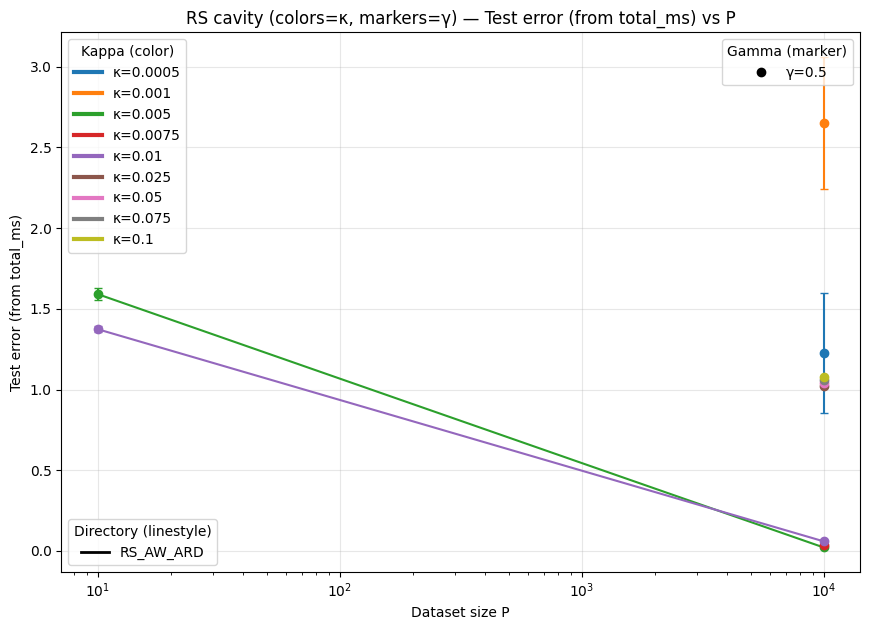

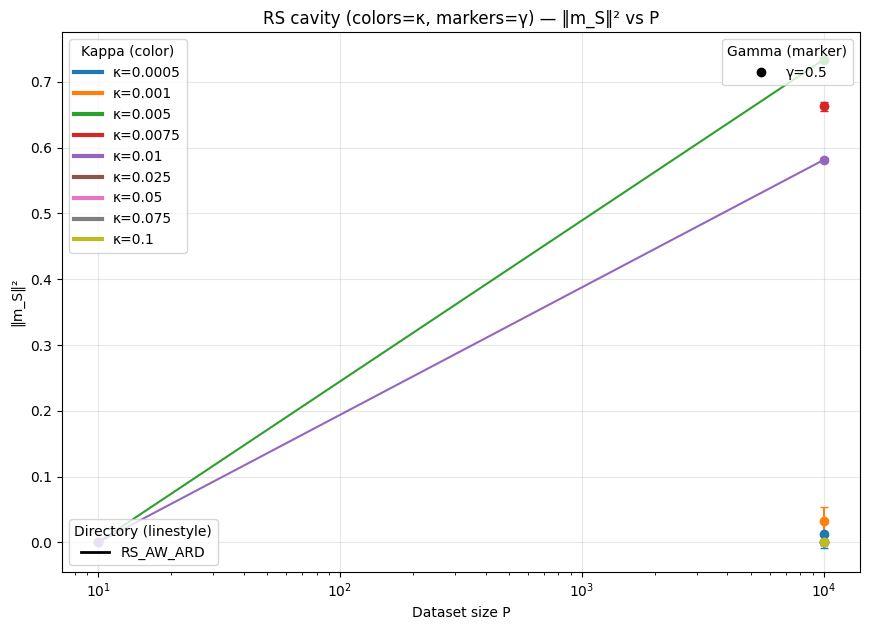

In [5]:
if __name__ == "__main__":
    pairs = [
        ("/home/goring/mean_field_langevin/MCMC_sparse/results/d35_k4_3108_a1grid", "RS_AW_ARD"),
        # add more (dir, label) tuples if you want distinct linestyles
    ]
    _ = plot_rs_aw_results(
        pairs,
        save_png=True,
        out_prefix="rs_aw_gamma_kappa_summaries",
        title_prefix="RS cavity (colors=κ, markers=γ)",
        xscale_log=True,
        # ylim_mse=(0.0, 1.0),
        # ylim_mS=(0.0, 1.0),
        also_plot_empirical=False,  # set True to also generate empirical-MSE figure
    )

--- RS_AW_ARD (/home/goring/mean_field_langevin/MCMC_sparse/results/d35_k4_3108_a1_plot) ---
  κ=0.0075  γ=0.5  P=    10  MSE(total_ms)=1.4948708298869253 ± 0.05420781044525819 (files=1)   ‖m_S‖²=1.2051754610493875e-05 ± 5.757079402068103e-06 (files=1)
    Empirical MSE=1.494870867735396 ± 0.054207833428771036 (files=1)
  κ=0.0075  γ=0.5  P=   100  MSE(total_ms)=1.454579265024525 ± 0.04159122388795886 (files=1)   ‖m_S‖²=5.641473911164322e-06 ± 4.864489607367442e-06 (files=1)
    Empirical MSE=1.4545792791371543 ± 0.04159128689953365 (files=1)
  κ=0.0075  γ=0.5  P=   500  MSE(total_ms)=1.2380690715541884 ± 0.0127567834561605 (files=1)   ‖m_S‖²=0.00018582325660512062 ± 0.0002540316322890044 (files=1)
    Empirical MSE=1.2380690415545057 ± 0.012756777115558787 (files=1)
  κ=0.0075  γ=0.5  P=   750  MSE(total_ms)=0.04596045489112536 ± 0.004108672402893892 (files=1)   ‖m_S‖²=0.6389032685806129 ± 0.014155214095616216 (files=1)
    Empirical MSE=0.045960466066996254 ± 0.004108667193081631 (fi

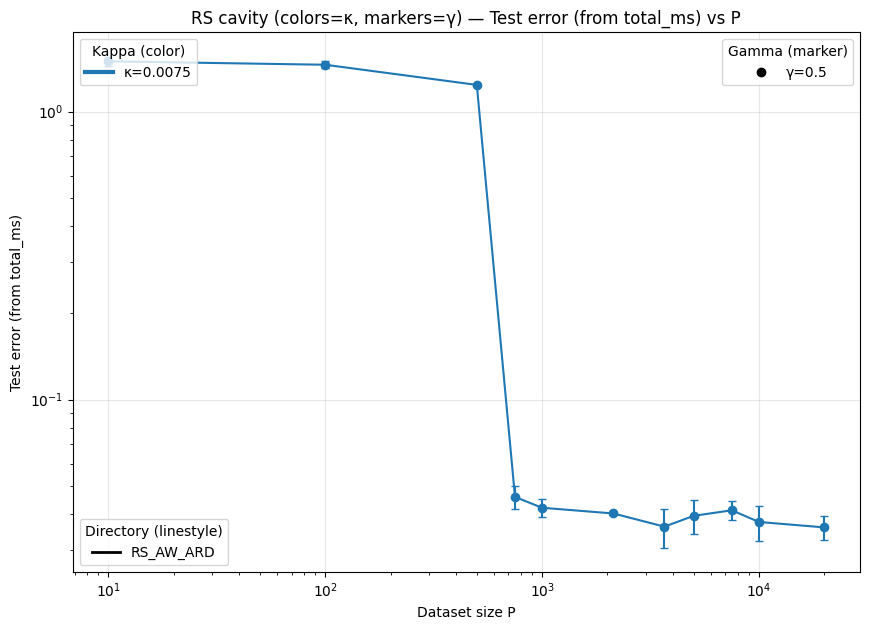

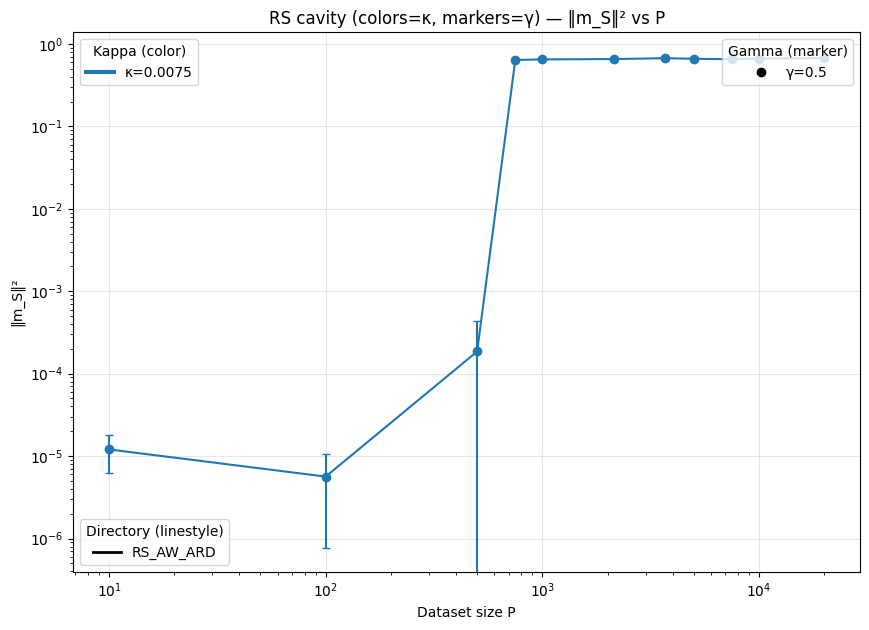

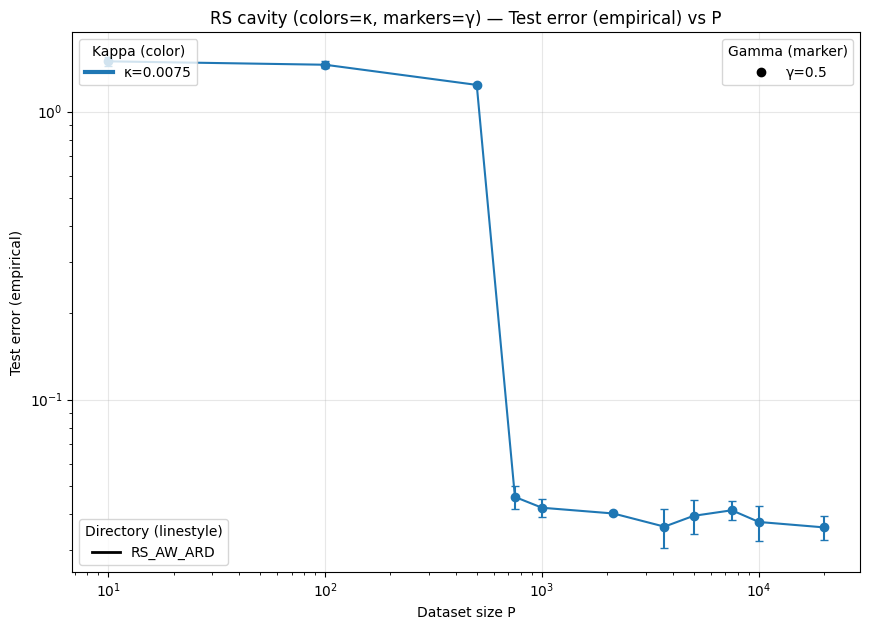

In [23]:
if __name__ == "__main__":
    pairs = [
        ("/home/goring/mean_field_langevin/MCMC_sparse/results/d35_k4_3108_a1_plot", "RS_AW_ARD"),
        # add more (dir, label) tuples if you want distinct linestyles
    ]
    _ = plot_rs_aw_results(
        pairs,
        save_png=True,
        out_prefix="rs_aw_gamma_kappa_summaries",
        title_prefix="RS cavity (colors=κ, markers=γ)",
        xscale_log=True,
        # ylim_mse=(0.0, 1.0),
        # ylim_mS=(0.0, 1.0),
        also_plot_empirical=True,  # set True to also generate empirical-MSE figure
    )

--- RS_AW_ARD (/home/goring/mean_field_langevin/MCMC_sparse/results/d35_k4_3108_a1grid_fix) ---
  κ=0.0075  γ=0.5  P=    10  MSE(total_ms)=1.426063056747201 ± 0.05760891843785954 (files=1)   ‖m_S‖²=8.775830186160649e-06 ± 2.3205902362604398e-06 (files=1)
    Empirical MSE=1.4260631462869544 ± 0.057608907631490056 (files=1)
  κ=0.0075  γ=0.5  P=   100  MSE(total_ms)=1.4955898289385914 ± 0.06929083502456655 (files=1)   ‖m_S‖²=9.699214989626113e-06 ± 5.8274601836419e-06 (files=1)
    Empirical MSE=1.4955898205128808 ± 0.06929077586067149 (files=1)
  κ=0.0075  γ=0.5  P=   750  MSE(total_ms)=0.04540744672218958 ± 0.009922878703293293 (files=1)   ‖m_S‖²=0.6393658839265619 ± 0.03707169403279609 (files=1)
    Empirical MSE=0.04540743430455526 ± 0.00992288313251522 (files=1)
  κ=0.0075  γ=0.5  P= 10000  MSE(total_ms)=0.028810436526934307 ± 0.001593476071526446 (files=1)   ‖m_S‖²=0.6994753633069699 ± 0.007201164197590182 (files=1)
    Empirical MSE=0.028810441493988037 ± 0.0015934890696197733 (f

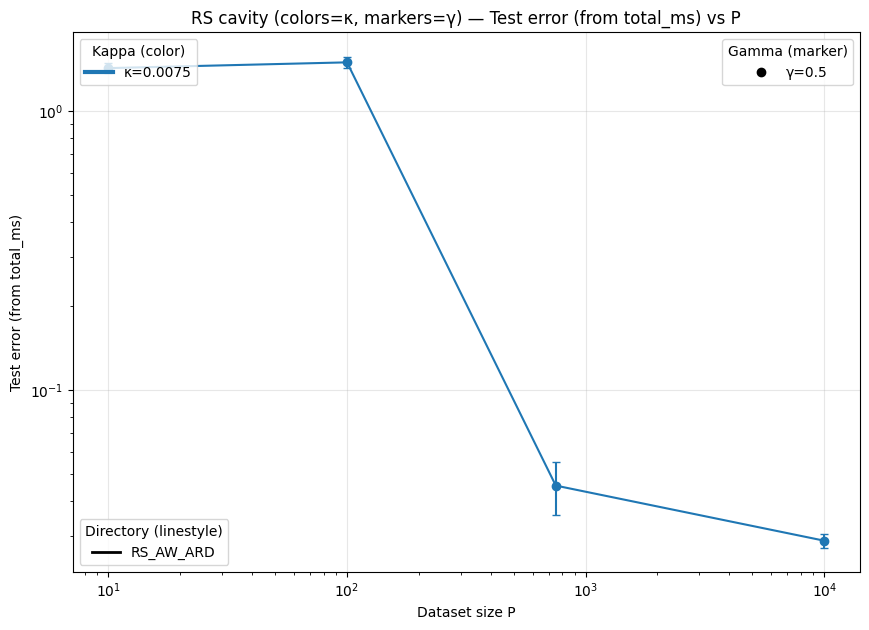

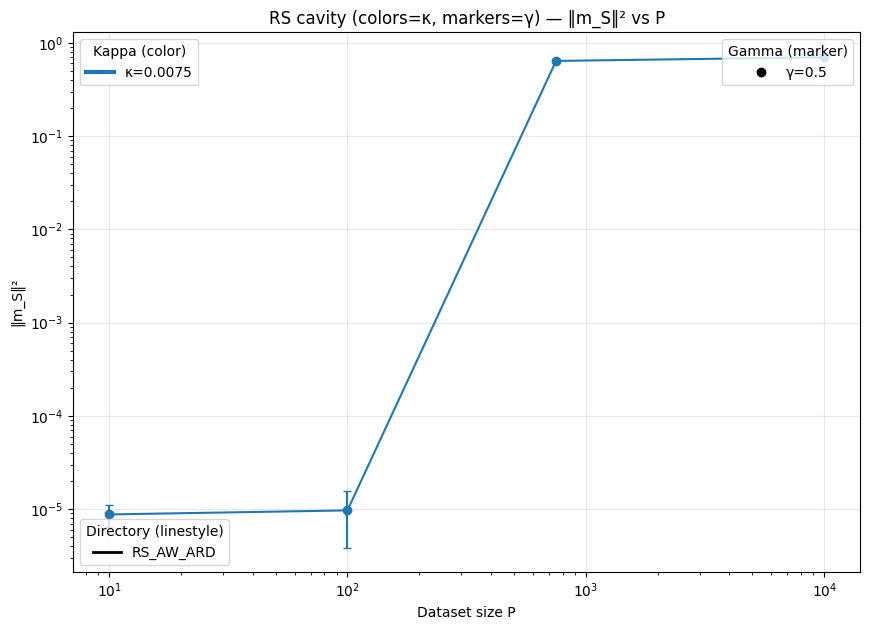

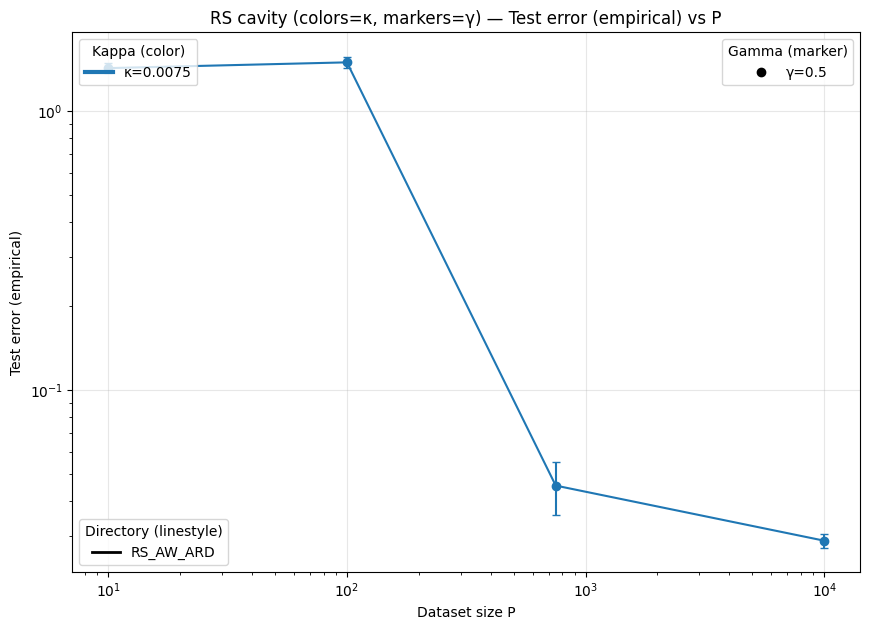

In [21]:
if __name__ == "__main__":
    pairs = [
        ("/home/goring/mean_field_langevin/MCMC_sparse/results/d35_k4_3108_a1grid_fix", "RS_AW_ARD"),
        # add more (dir, label) tuples if you want distinct linestyles
    ]
    _ = plot_rs_aw_results(
        pairs,
        save_png=True,
        out_prefix="rs_aw_gamma_kappa_summaries",
        title_prefix="RS cavity (colors=κ, markers=γ)",
        xscale_log=True,
        # ylim_mse=(0.0, 1.0),
        # ylim_mS=(0.0, 1.0),
        also_plot_empirical=True,  # set True to also generate empirical-MSE figure
    )

--- RS_AW_ARD (/home/goring/mean_field_langevin/MCMC_sparse/results/d35_k4_3108_a1grid_fix_nomala) ---
  κ=0.0075  γ=0.5  P=    10  MSE(total_ms)=1.571115838068143 ± 0.14617670456193502 (files=1)   ‖m_S‖²=2.5474450780823602e-05 ± 2.1281853916814847e-05 (files=1)
    Empirical MSE=1.5711159019265324 ± 0.146176676992391 (files=1)
  κ=0.0075  γ=0.5  P=   100  MSE(total_ms)=1.4431974379803212 ± 0.051633197326433115 (files=1)   ‖m_S‖²=7.431846238581113e-06 ± 9.619190794977247e-06 (files=1)
    Empirical MSE=1.4431973667427276 ± 0.05163314639514906 (files=1)
  κ=0.0075  γ=0.5  P=   750  MSE(total_ms)=0.029769374678532284 ± 0.0017315687078079906 (files=1)   ‖m_S‖²=0.6922128137407443 ± 0.0075299962779846585 (files=1)
    Empirical MSE=0.02976936101913452 ± 0.0017315813337452392 (files=1)
  κ=0.0075  γ=0.5  P=  1000  MSE(total_ms)=0.03378245731194814 ± 0.0025702965266201096 (files=1)   ‖m_S‖²=0.6768552808938194 ± 0.009916460664790218 (files=1)
    Empirical MSE=0.03378246227900187 ± 0.002570316

[saved plot] rs_aw_gamma_kappa_summaries_mS_vs_P.png
[saved plot] rs_aw_gamma_kappa_summaries_mse_empirical_vs_P.png


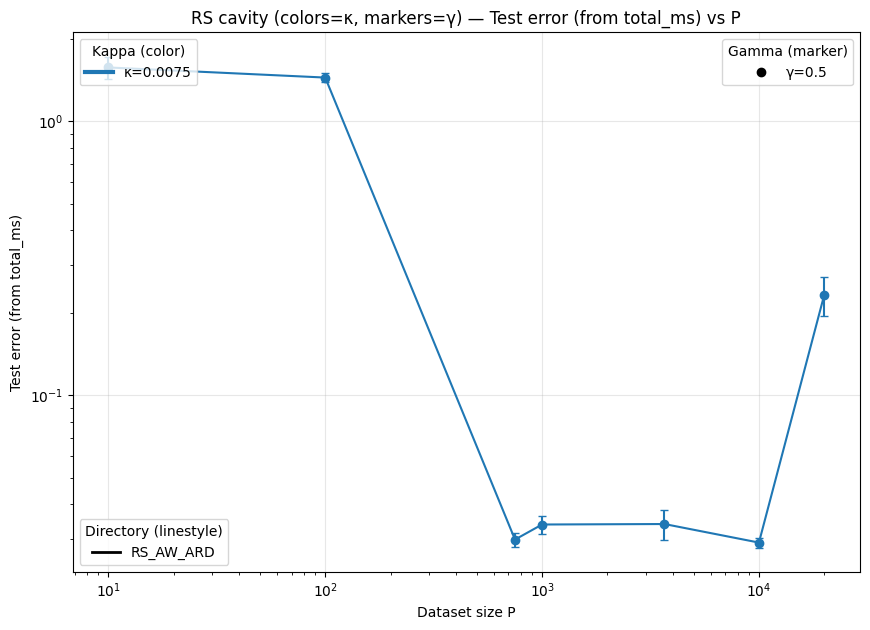

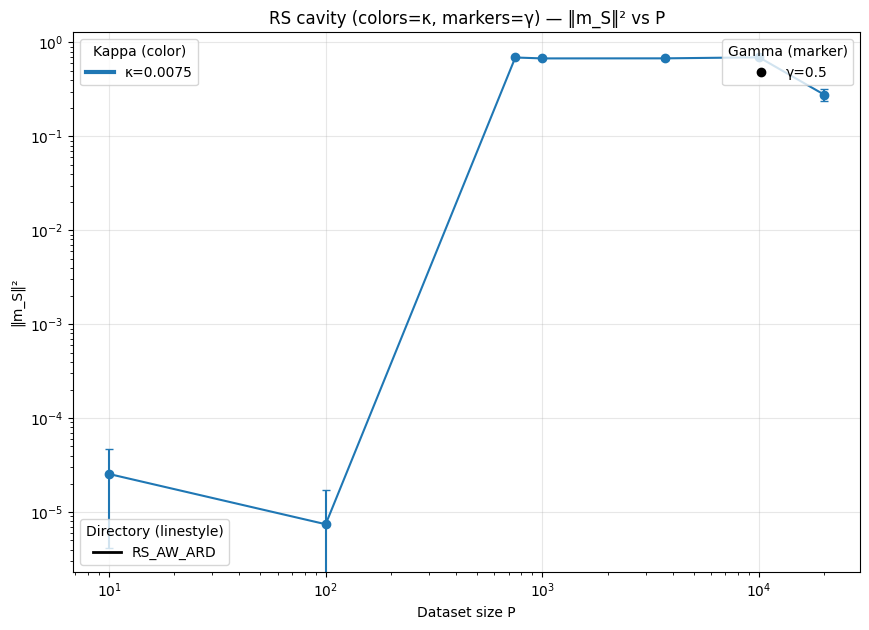

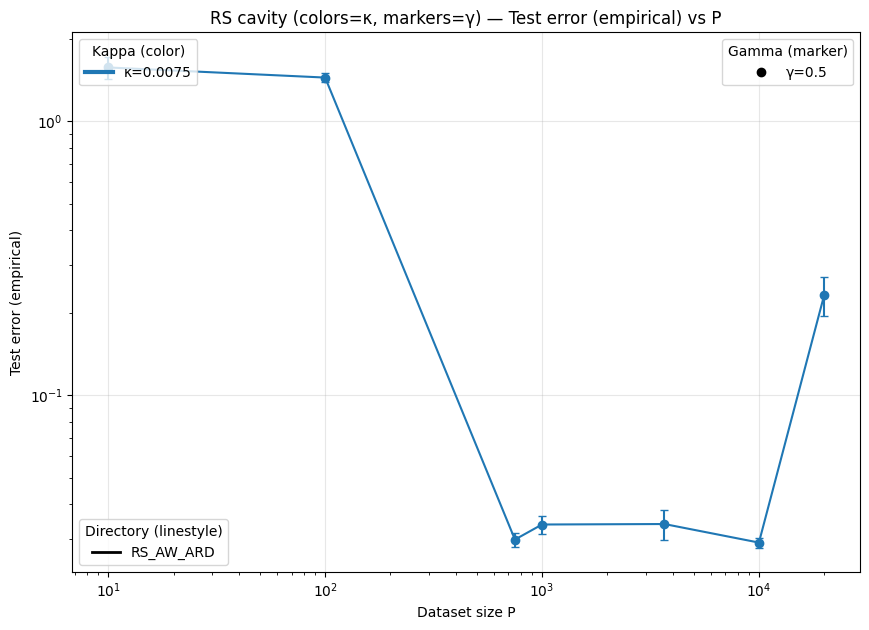

In [22]:
if __name__ == "__main__":
    pairs = [
        ("/home/goring/mean_field_langevin/MCMC_sparse/results/d35_k4_3108_a1grid_fix_nomala", "RS_AW_ARD"),
        # add more (dir, label) tuples if you want distinct linestyles
    ]
    _ = plot_rs_aw_results(
        pairs,
        save_png=True,
        out_prefix="rs_aw_gamma_kappa_summaries",
        title_prefix="RS cavity (colors=κ, markers=γ)",
        xscale_log=True,
        # ylim_mse=(0.0, 1.0),
        # ylim_mS=(0.0, 1.0),
        also_plot_empirical=True,  # set True to also generate empirical-MSE figure
    )

--- 1N (/home/goring/mean_field_langevin/MCMC_sparse/results/d35_k4_0109_a1grid_fix_nomala_1N_exact_3) ---
  κ=0.0075  γ=0.5  P=    50  MSE(total_ms)=1.627047637012467 ± 0.11571794630920114 (files=1)   ‖m_S‖²=5.772641711331974e-07 ± 4.0156956276150455e-07 (files=1)
    Empirical MSE=1.6270476781452696 ± 0.1157178994620578 (files=1)
  κ=0.0075  γ=0.5  P=   100  MSE(total_ms)=1.423671581991357 ± 0.10989066736426512 (files=1)   ‖m_S‖²=1.0759981806326646e-05 ± 1.154648718569495e-05 (files=1)
    Empirical MSE=1.423671583024164 ± 0.10989070973996079 (files=1)
  κ=0.0075  γ=0.5  P=   750  MSE(total_ms)=1.0329915271916736 ± 0.048501422734381745 (files=1)   ‖m_S‖²=0.004598206646589724 ± 0.0023176668229667376 (files=1)
    Empirical MSE=1.0329914912581444 ± 0.04850143202538026 (files=1)
  κ=0.0075  γ=0.5  P= 10000  MSE(total_ms)=0.6194432005286217 ± 0.05203748952715372 (files=1)   ‖m_S‖²=0.04941153742045231 ± 0.01399760377275552 (files=1)
    Empirical MSE=0.6194431719680628 ± 0.052037478722687

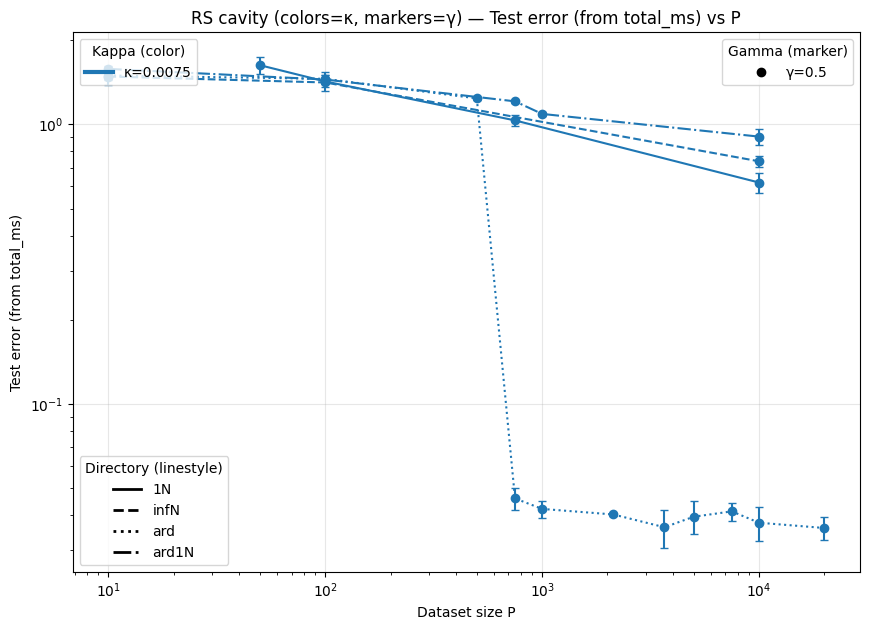

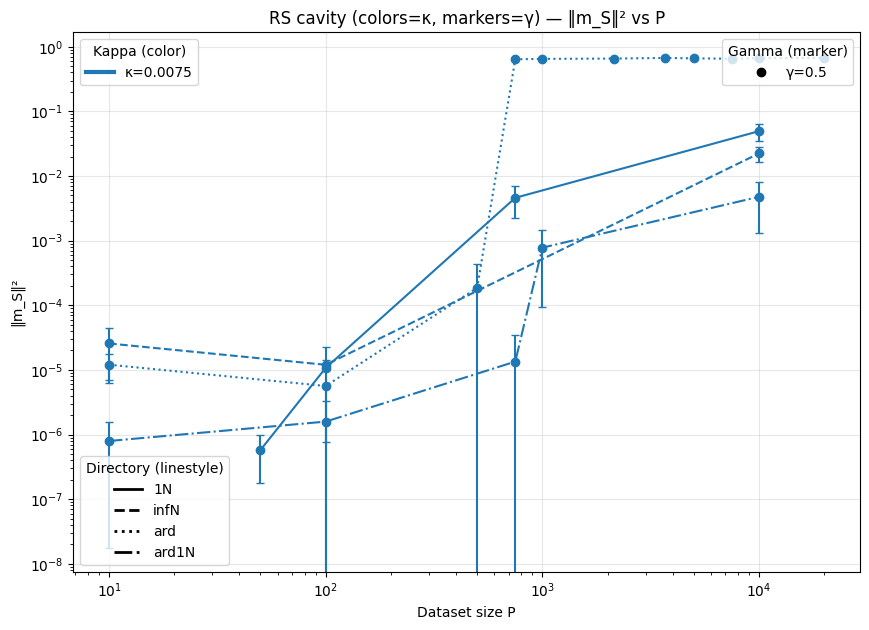

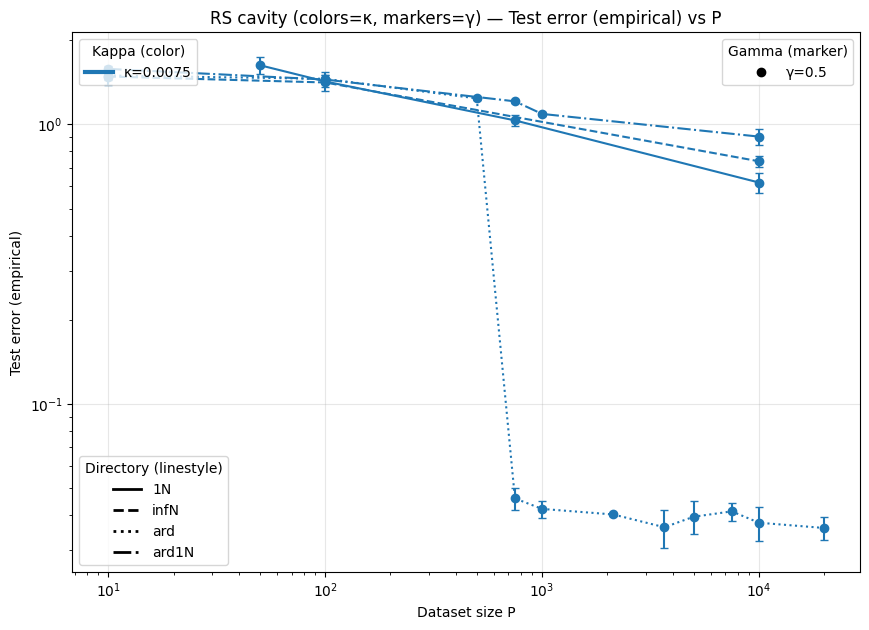

In [57]:
if __name__ == "__main__":
    pairs = [
        ("/home/goring/mean_field_langevin/MCMC_sparse/results/d35_k4_0109_a1grid_fix_nomala_1N_exact_3","1N"),
        ("/home/goring/mean_field_langevin/MCMC_sparse/results/d35_k4_3108_a1grid_fix_nomala_1N_false","infN"),
        ("/home/goring/mean_field_langevin/MCMC_sparse/results/d35_k4_3108_a1_plot", "ard"),
        ("/home/goring/mean_field_langevin/MCMC_sparse/results/d35_k4_0109_a1grid_fix_mala_1N_exact_4","ard1N"),
        # add more (dir, label) tuples if you want distinct linestyles
    ]
    _ = plot_rs_aw_results(
        pairs,
        save_png=True,
        out_prefix="rs_aw_gamma_kappa_summaries",
        title_prefix="RS cavity (colors=κ, markers=γ)",
        xscale_log=True,
        # ylim_mse=(0.0, 1.0),
        # ylim_mS=(0.0, 1.0),
        also_plot_empirical=True,  # set True to also generate empirical-MSE figure
    )

--- 1N_ard (/home/goring/mean_field_langevin/MCMC_sparse/results/01_09_exp_d35_k4_1N_ard) ---
  κ=0.0075  γ=0.5  P=    25  MSE(total_ms)=1.5765596402409063 ± 0.05631680533853116 (files=1)   ‖m_S‖²=2.7445234663912046e-06 ± 3.480522698385737e-06 (files=1)
    Empirical MSE=1.5765596902153145 ± 0.056316760095972376 (files=1)
  κ=0.0075  γ=0.5  P=   100  MSE(total_ms)=1.6467996110710221 ± 0.058899940149531656 (files=1)   ‖m_S‖²=1.0781467957658286e-05 ± 7.81239548858469e-06 (files=1)
    Empirical MSE=1.6467995909818758 ± 0.05889991310802148 (files=1)
  κ=0.0075  γ=0.5  P=   750  MSE(total_ms)=0.035692254081368446 ± 0.005718552720867743 (files=1)   ‖m_S‖²=0.6741354858712091 ± 0.024434011506579055 (files=1)
    Empirical MSE=0.03569225470225016 ± 0.0057185453465759244 (files=1)
  κ=0.0075  γ=0.5  P=  1000  MSE(total_ms)=0.03592348347107569 ± 0.0025478043863507013 (files=1)   ‖m_S‖²=0.671825231779606 ± 0.010979891860555889 (files=1)
    Empirical MSE=0.035923500855763756 ± 0.00254780617253071

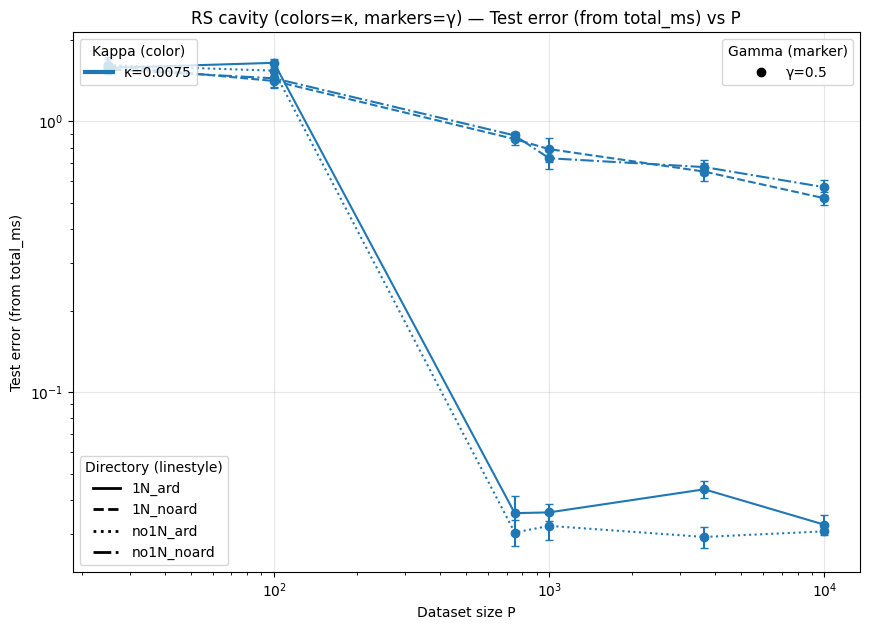

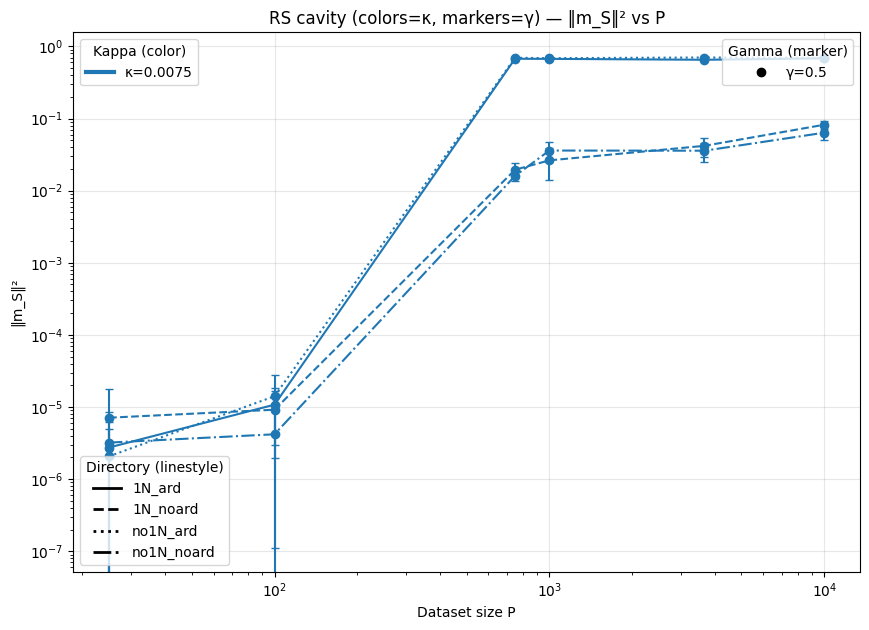

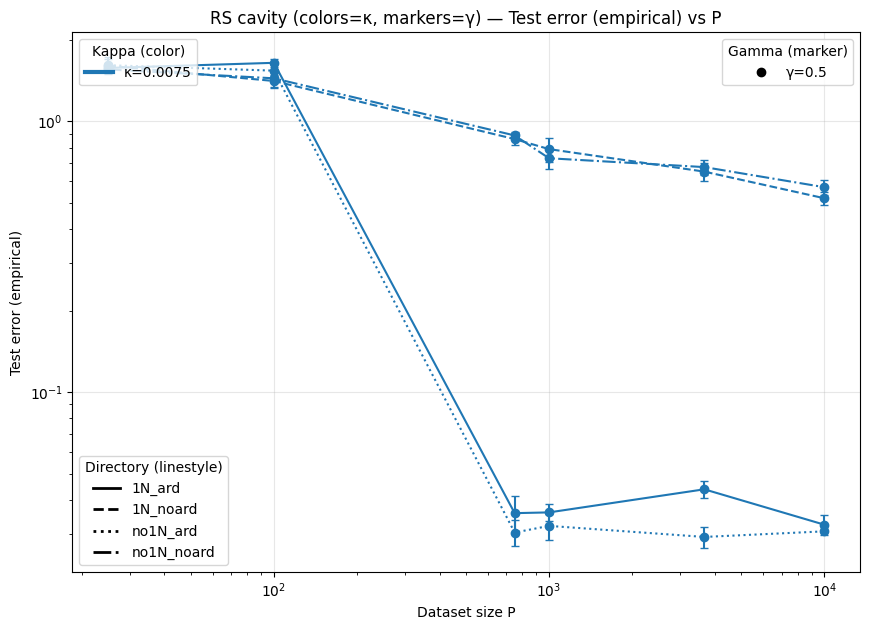

In [3]:
if __name__ == "__main__":
    pairs = [
        ("/home/goring/mean_field_langevin/MCMC_sparse/results/01_09_exp_d35_k4_1N_ard","1N_ard"),
        ("/home/goring/mean_field_langevin/MCMC_sparse/results/01_09_exp_d35_k4_1N_noard","1N_noard"),
        ("/home/goring/mean_field_langevin/MCMC_sparse/results/01_09_exp_d35_k4_no1N_ard", "no1N_ard"),
        ("/home/goring/mean_field_langevin/MCMC_sparse/results/01_09_exp_d35_k4_no1N_noard","no1N_noard"),
        # add more (dir, label) tuples if you want distinct linestyles
    ]
    _ = plot_rs_aw_results(
        pairs,
        save_png=True,
        out_prefix="rs_aw_gamma_kappa_summaries",
        title_prefix="RS cavity (colors=κ, markers=γ)",
        xscale_log=True,
        # ylim_mse=(0.0, 1.0),
        # ylim_mS=(0.0, 1.0),
        also_plot_empirical=True,  # set True to also generate empirical-MSE figure
    )

--- small (/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm/ard_a1_no1N_5e-4+1e-3) ---
  κ=0.0005  γ=0.5  P=    10  MSE(total_ms)=1.4257160067996513 ± 0.011678910135831206 (files=1)   ‖m_S‖²=6.2942066054416175e-06 ± 5.919180100858998e-06 (files=1)
    Empirical MSE=1.4257159830691915 ± 0.011678850914482817 (files=1)
  κ=0.0005  γ=0.5  P=   100  MSE(total_ms)=1.6312371767932532 ± 0.18821779427305602 (files=1)   ‖m_S‖²=3.6579992771846453e-06 ± 6.01234002983905e-06 (files=1)
    Empirical MSE=1.631237133774145 ± 0.188217832181411 (files=1)
  κ=0.0005  γ=0.5  P=   500  MSE(total_ms)=1.398960248723976 ± 0.007747144942658526 (files=1)   ‖m_S‖²=0.00018180798364170344 ± 0.00018518815166747467 (files=1)
    Empirical MSE=1.3989602643220376 ± 0.007747193668226698 (files=1)
  κ=0.0005  γ=0.5  P=   750  MSE(total_ms)=1.0858440042162936 ± 0.17248049208674368 (files=1)   ‖m_S‖²=0.02216690354265416 ± 0.016881944726698263 (files=1)
    Empirical MSE=1.085843990246455 ± 0.172480523526715

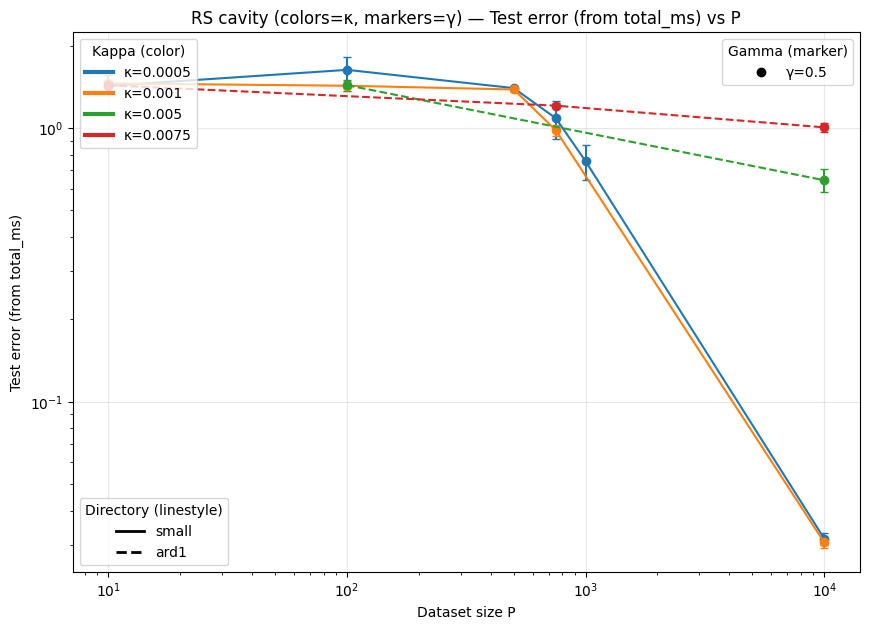

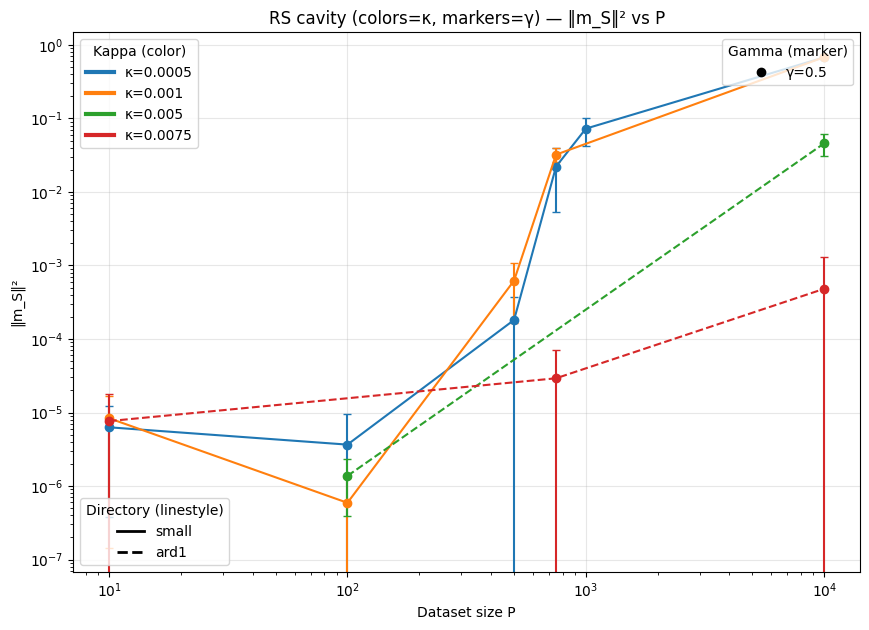

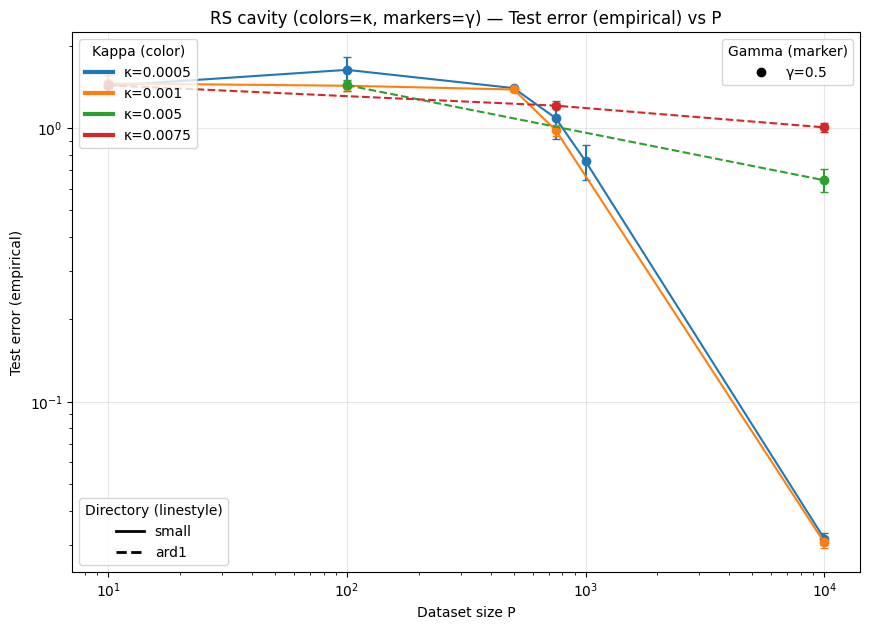

In [29]:
if __name__ == "__main__":
    pairs = [
        #("/home/goring/mean_field_langevin/MCMC_sparse/results/01_09_exp_d35_k4_no1N_ard50","50"),
        #("/home/goring/mean_field_langevin/MCMC_sparse/results/01_09_exp_d35_k4_no1N_ard1e-6","1e-6"),
        #("/home/goring/mean_field_langevin/MCMC_sparse/results/01_09_exp_d35_k4_no1N_ard", "no1N_ard"),
        #("/home/goring/mean_field_langevin/MCMC_sparse/results/01_09_exp_d35_k4_no1N_ard1e-2_k0.0005","small"),
        ("/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm/ard_a1_no1N_5e-4+1e-3","small"),
        #("/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm/ard_a10_no1N_7.5e-3+5e-3","arda10"),
        ("/home/goring/mean_field_langevin/MCMC_composite/results_d35k4hm/ard_a1_no1N_7.5e-3+5e-3","ard1")
        # add more (dir, label) tuples if you want distinct linestyles
    ]
    _ = plot_rs_aw_results(
        pairs,
        save_png=True,
        out_prefix="rs_aw_gamma_kappa_summaries",
        title_prefix="RS cavity (colors=κ, markers=γ)",
        xscale_log=True,
        # ylim_mse=(0.0, 1.0),
        # ylim_mS=(0.0, 1.0),
        also_plot_empirical=True,  # set True to also generate empirical-MSE figure
    )